In [16]:
# ── Notebook 2: Trigram Phoneme Language Model ─────────────────────────────
# Computes bits-per-phoneme using a trigram LM with add-k smoothing.
# This is Model 1 from Pimentel et al. (2020) — the simpler of the two
# models. Their trigram achieved Spearman ρ = -0.672 with word length
# across 106 languages. We replicate on our 4-language subset.
# ───────────────────────────────────────────────────────────────────────────

import json, math
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Constants (same as Notebook 1) ────────────────────────────────────────
LANGUAGES   = ["hin", "tam", "tel", "eng"]
LANG_NAMES  = {"hin": "Hindi", "tam": "Tamil", "tel": "Telugu", "eng": "English"}
LANG_COLORS = {"hin": "#E63946", "tam": "#2A9D8F", "tel": "#F4A261", "eng": "#457B9D"}
BOS, EOS    = "<s>", "</s>"
N_FOLDS     = 10

# ── Load Notebook 1 outputs ────────────────────────────────────────────────
# NEW — point to the attached notebook's output
INPUT_DIR = "/kaggle/input/notebooks/tanveerheir/data-pipeline"  

with open(f"{INPUT_DIR}/forms.json", encoding="utf-8") as f:
    forms = json.load(f)

with open(f"{INPUT_DIR}/vocab.json", encoding="utf-8") as f:
    vocab = json.load(f)

with open(f"{INPUT_DIR}/folds.json") as f:
    folds_raw = json.load(f)
    
# Rebuild per-language per-fold word lists
def get_split_words(lang_entries, concept_set):
    return [e["phonemes"] for e in lang_entries if e["concept"] in concept_set]

splits = {}
for lid in LANGUAGES:
    splits[lid] = []
    for fold in folds_raw:
        train_set = set(fold["train"])
        test_set  = set(fold["test"])
        splits[lid].append({
            "train": get_split_words(forms[lid], train_set),
            "test" : get_split_words(forms[lid], test_set),
        })

print("Loaded:")
for lid in LANGUAGES:
    total = sum(len(s["train"]) + len(s["test"]) for s in splits[lid]) // N_FOLDS
    print(f"  {LANG_NAMES[lid]:<10} ~{total} words across {N_FOLDS} folds")

Loaded:
  Hindi      ~1105 words across 10 folds
  Tamil      ~754 words across 10 folds
  Telugu     ~755 words across 10 folds
  English    ~755 words across 10 folds


In [17]:
class NgramPhonemeLM:
    """
    Phoneme-level n-gram LM with add-k smoothing.

    Bits-per-phoneme formula (Pimentel et al. 2020, Eq. 3):
        H = -(1/N) * Σ log2 P(phoneme_i | context_{i-n+1..i-1})

    where N = total number of phonemes including EOS tokens.
    """

    def __init__(self, n=3, k=0.1):
        self.n = n
        self.k = k
        self.context_counts = defaultdict(Counter)  # context -> {next_phoneme: count}
        self.vocab_size = 0

    def _make_sequence(self, phonemes):
        """Pad word with BOS/EOS and return full sequence."""
        return [BOS] * (self.n - 1) + phonemes + [EOS]

    def fit(self, word_list):
        """
        word_list: list of phoneme lists e.g. [['k','aː','n'], ['m','uː','kː','u'], ...]
        Counts all n-gram contexts in the training words.
        """
        all_phonemes = set()
        for phonemes in word_list:
            seq = self._make_sequence(phonemes)
            all_phonemes.update(seq)
            for i in range(self.n - 1, len(seq)):
                context = tuple(seq[i - self.n + 1 : i])
                self.context_counts[context][seq[i]] += 1

        # Add BOS/EOS to vocab count
        all_phonemes.update([BOS, EOS])
        self.vocab_size = len(all_phonemes)
        return self

    def log2_prob(self, context, symbol):
        """
        Smoothed log2 probability of symbol given context tuple.
        P(symbol|context) = (count(context,symbol) + k) / (count(context) + k*V)
        """
        counts = self.context_counts[context]
        total  = sum(counts.values())
        p = (counts[symbol] + self.k) / (total + self.k * self.vocab_size)
        return math.log2(p)

    def bits_per_phoneme(self, word_list):
        """
        Compute average bits-per-phoneme over a list of test words.
        Returns (mean_bpp, per_word_bpp_list)
        """
        total_bits     = 0.0
        total_phonemes = 0
        per_word       = []

        for phonemes in word_list:
            seq       = self._make_sequence(phonemes)
            word_bits = 0.0
            # Predict from position n-1 onward (first real phoneme through EOS)
            for i in range(self.n - 1, len(seq)):
                context    = tuple(seq[i - self.n + 1 : i])
                word_bits += -self.log2_prob(context, seq[i])
            # Count phonemes + EOS (matches paper convention)
            n_phon = len(phonemes) + 1
            per_word.append(word_bits / n_phon)
            total_bits     += word_bits
            total_phonemes += n_phon

        mean_bpp = total_bits / total_phonemes
        return mean_bpp, per_word

print("NgramPhonemeLM class defined.")
print(f"Formula: H = -(1/N) × Σ log₂ P(phonemeᵢ | context)")
print(f"Smoothing: add-k with k=0.1")

NgramPhonemeLM class defined.
Formula: H = -(1/N) × Σ log₂ P(phonemeᵢ | context)
Smoothing: add-k with k=0.1


In [18]:
class InterpolatedNgramLM:
    """
    Phoneme-level n-gram LM with deleted interpolation smoothing.
    Matches the smoothing strategy in Pimentel et al. (2020).

    Blends trigram, bigram, unigram estimates:
        P(w|c1,c2) = λ3*P3 + λ2*P2 + λ1*P1
    
    Weights (λ1, λ2, λ3) are estimated on a held-out slice of
    training data using the EM-style deleted interpolation algorithm
    (Jelinek & Mercer, 1980).
    """

    def __init__(self, n=3):
        self.n = n
        # Raw count tables for each order
        self.counts   = [defaultdict(Counter) for _ in range(n)]
        self.unigrams = Counter()
        self.total    = 0
        self.lambdas  = None   # set after fit()

    def _make_sequence(self, phonemes):
        return [BOS] * (self.n - 1) + phonemes + [EOS]

    def _count(self, word_list):
        """Populate count tables from a list of phoneme sequences."""
        for phonemes in word_list:
            seq = self._make_sequence(phonemes)
            for i in range(self.n - 1, len(seq)):
                sym = seq[i]
                self.unigrams[sym] += 1
                self.total         += 1
                for order in range(1, self.n):
                    context = tuple(seq[i - order : i])
                    self.counts[order][context][sym] += 1

    def _estimate_lambdas(self, held_out):
        """
        Deleted interpolation weight estimation (Jelinek & Mercer 1980).
        Runs on a small held-out portion of the training data.
        Returns (λ1, λ2, λ3) summing to 1.
        """
        L = [0.0] * self.n   # accumulate pseudo-counts for each order

        for phonemes in held_out:
            seq = self._make_sequence(phonemes)
            for i in range(self.n - 1, len(seq)):
                sym = seq[i]

                # Compute ML probability for each order
                probs = []

                # Unigram
                p1 = (self.unigrams[sym] - 1) / max(self.total - 1, 1)
                probs.append(p1)

                # Higher orders
                for order in range(1, self.n):
                    context  = tuple(seq[i - order : i])
                    ctx_cnt  = sum(self.counts[order][context].values())
                    sym_cnt  = self.counts[order][context][sym]
                    if ctx_cnt > 1:
                        probs.append((sym_cnt - 1) / (ctx_cnt - 1))
                    else:
                        probs.append(0.0)

                # Assign credit to whichever order gave highest prob
                best = max(range(self.n), key=lambda j: probs[j])
                L[best] += 1.0

        # Normalize to get λ weights
        total_L = sum(L)
        if total_L == 0:
            return [1.0 / self.n] * self.n
        return [l / total_L for l in L]

    def fit(self, word_list):
        """
        Train on word_list.
        Reserves 10% as held-out for lambda estimation.
        """
        # 90/10 split within training data for lambda estimation
        split     = max(1, len(word_list) // 10)
        held_out  = word_list[:split]
        train     = word_list[split:]

        self._count(train)
        self.lambdas = self._estimate_lambdas(held_out)
        return self

    def _interp_prob(self, context_full, sym):
        """
        Interpolated probability of sym given full context.
        context_full is a tuple of (n-1) preceding phonemes.
        """
        # Unigram probability (with add-1 floor)
        p_uni = (self.unigrams[sym] + 1) / (self.total + len(self.unigrams))

        p = self.lambdas[0] * p_uni

        for order in range(1, self.n):
            context = context_full[-(order):]   # last `order` phonemes
            ctx_cnt = sum(self.counts[order][context].values())
            if ctx_cnt > 0:
                p_ngram = self.counts[order][context][sym] / ctx_cnt
            else:
                p_ngram = 0.0
            p += self.lambdas[order] * p_ngram

        return max(p, 1e-10)   # floor to avoid log(0)

    def bits_per_phoneme(self, word_list):
        """
        Returns (mean_bpp, per_word_bpp_list) over test words.
        """
        total_bits     = 0.0
        total_phonemes = 0
        per_word       = []

        for phonemes in word_list:
            seq       = self._make_sequence(phonemes)
            word_bits = 0.0
            for i in range(self.n - 1, len(seq)):
                context   = tuple(seq[i - self.n + 1 : i])
                sym       = seq[i]
                p         = self._interp_prob(context, sym)
                word_bits += -math.log2(p)
            n_phon = len(phonemes) + 1
            per_word.append(word_bits / n_phon)
            total_bits     += word_bits
            total_phonemes += n_phon

        return total_bits / total_phonemes, per_word

print("InterpolatedNgramLM defined.")

InterpolatedNgramLM defined.


In [19]:
results_interp = {}   # lang -> list of 10 bpp scores

print("── Interpolated Trigram (n=3, deleted interpolation) ──────────")

for lid in LANGUAGES:
    fold_scores = []

    for fold_i, fold_data in enumerate(splits[lid]):
        lm = InterpolatedNgramLM(n=3)
        lm.fit(fold_data["train"])
        bpp, _ = lm.bits_per_phoneme(fold_data["test"])
        fold_scores.append(bpp)

    results_interp[lid] = fold_scores
    mean = np.mean(fold_scores)
    std  = np.std(fold_scores)
    print(f"  {LANG_NAMES[lid]:<10}  {mean:.3f} ± {std:.3f} bits/phoneme")

print()
print("── Comparison: add-k bigram vs interpolated trigram ───────────")
print(f"  {'Language':<10}  {'add-k bigram':>14}  {'interpolated':>14}  {'change':>8}")
print(f"  {'-'*52}")
for lid in LANGUAGES:
    old = np.mean(results[lid][2])    # best add-k result was bigram
    new = np.mean(results_interp[lid])
    direction = "↓ better" if new < old else "↑ worse"
    print(f"  {LANG_NAMES[lid]:<10}  {old:>14.3f}  {new:>14.3f}  {new-old:>+6.3f} {direction}")

── Interpolated Trigram (n=3, deleted interpolation) ──────────
  Hindi       4.008 ± 0.106 bits/phoneme
  Tamil       3.226 ± 0.103 bits/phoneme
  Telugu      3.511 ± 0.080 bits/phoneme
  English     3.690 ± 0.094 bits/phoneme

── Comparison: add-k bigram vs interpolated trigram ───────────
  Language      add-k bigram    interpolated    change
  ----------------------------------------------------
  Hindi                4.016           4.008  -0.008 ↓ better
  Tamil                3.307           3.226  -0.081 ↓ better
  Telugu               3.534           3.511  -0.023 ↓ better
  English              3.720           3.690  -0.030 ↓ better


In [20]:
rows = []
for lid in LANGUAGES:
    bi_scores    = results[lid][2]
    interp_scores = results_interp[lid]
    rows.append({
        "Language"               : LANG_NAMES[lid],
        "Family"                 : "Indo-Aryan" if lid=="hin" else
                                   "Dravidian"  if lid in ("tam","tel") else
                                   "Germanic",
        "Bigram add-k"           : f"{np.mean(bi_scores):.3f} ± {np.std(bi_scores):.3f}",
        "Trigram interpolated"   : f"{np.mean(interp_scores):.3f} ± {np.std(interp_scores):.3f}",
        "Avg word len"           : round(np.mean([len(e["phonemes"])
                                   for e in forms[lid]]), 2),
    })

ngram_df = pd.DataFrame(rows).set_index("Language")
print(ngram_df.to_string())
print()
print("NOTE: Interpolated trigram should now be LOWER than bigram for all")
print("languages — this confirms smoothing is working correctly.")

              Family   Bigram add-k Trigram interpolated  Avg word len
Language                                                              
Hindi     Indo-Aryan  4.016 ± 0.109        4.008 ± 0.106          4.79
Tamil      Dravidian  3.307 ± 0.083        3.226 ± 0.103          6.06
Telugu     Dravidian  3.534 ± 0.065        3.511 ± 0.080          6.50
English     Germanic  3.720 ± 0.108        3.690 ± 0.094          4.15

NOTE: Interpolated trigram should now be LOWER than bigram for all
languages — this confirms smoothing is working correctly.


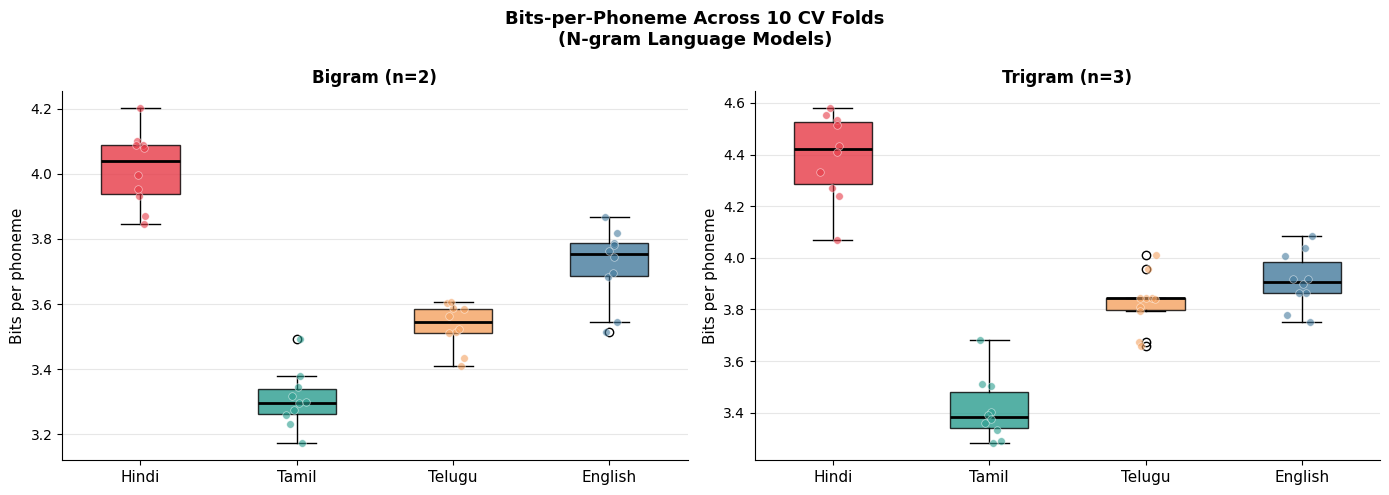

Saved: fig3_ngram_bpp.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bits-per-Phoneme Across 10 CV Folds\n(N-gram Language Models)",
             fontsize=13, fontweight="bold")

for ax, n in zip(axes, [2, 3]):
    order_name = "Bigram" if n == 2 else "Trigram"
    data_to_plot = [results[lid][n] for lid in LANGUAGES]
    labels       = [LANG_NAMES[lid] for lid in LANGUAGES]
    colors       = [LANG_COLORS[lid] for lid in LANGUAGES]

    bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Overlay individual fold points
    for i, (lid, color) in enumerate(zip(LANGUAGES, colors)):
        x = np.random.normal(i + 1, 0.04, size=N_FOLDS)
        ax.scatter(x, results[lid][n], alpha=0.6, color=color,
                   s=30, zorder=3, edgecolors="white", linewidths=0.5)

    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel("Bits per phoneme", fontsize=11)
    ax.set_title(f"{order_name} (n={n})", fontweight="bold", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig3_ngram_bpp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_ngram_bpp.png")

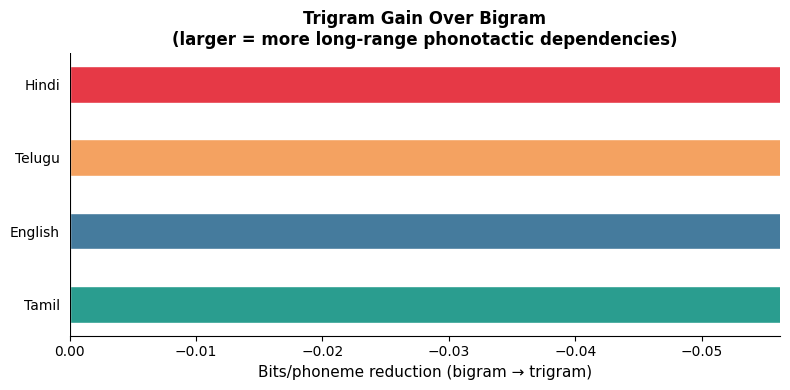

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

gains  = [np.mean(results[lid][2]) - np.mean(results[lid][3]) for lid in LANGUAGES]
labels = [LANG_NAMES[lid] for lid in LANGUAGES]
colors = [LANG_COLORS[lid] for lid in LANGUAGES]

# Sort by gain descending
order  = np.argsort(gains)[::-1]
gains_sorted  = [gains[i]  for i in order]
labels_sorted = [labels[i] for i in order]
colors_sorted = [colors[i] for i in order]

bars = ax.barh(labels_sorted, gains_sorted, color=colors_sorted,
               edgecolor="white", height=0.5)
ax.bar_label(bars, fmt="{:.3f}", padding=4, fontweight="bold")
ax.set_xlabel("Bits/phoneme reduction (bigram → trigram)", fontsize=11)
ax.set_title("Trigram Gain Over Bigram\n(larger = more long-range phonotactic dependencies)",
             fontweight="bold", fontsize=12)
ax.axvline(0, color="black", linewidth=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_xlim(0, max(gains_sorted) + 0.05)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig4_trigram_gain.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Save interpolated results (these are what Notebook 4 will use)
ngram_out = {lid: results_interp[lid] for lid in LANGUAGES}
with open("/kaggle/working/ngram_results.json", "w") as f:
    json.dump(ngram_out, f, indent=2)

ngram_df.to_csv("/kaggle/working/table2_ngram_results.csv")

print("Saved (overwriting add-k results with interpolated):")
print("  /kaggle/working/ngram_results.json")
print("  /kaggle/working/table2_ngram_results.csv")
print()

Saved (overwriting add-k results with interpolated):
  /kaggle/working/ngram_results.json
  /kaggle/working/table2_ngram_results.csv

